# Study 3 — Results: Directed-Step Scale (`xi_step_scale`) Sweep

Loads cached results from `../outputs/study3_full/` (1 400 runs: 7 values of
`xi_step_scale` × 100 images × 2 models, 2 000 queries each).

Fixed hyperparameters (Study 1's individually-best, combined for the first time):
`bs_steps=15, tau=1, lam_override=14, cmu_scale=1.0`.

`xi_step = xi * xi_step_scale`. Grid: `0.0180 (=1/sqrt(3072), old "broken"
xi_correction=True)`, `0.0625`, `0.125`, `0.25`, `0.5`, `1.0 (old
xi_correction=False)`, `2.0 (untested, beyond old baseline)`.


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = '../outputs/study3_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


1400 runs total, 1330 successful (95.0%)


,condition,model,image_idx,true_class,success,queries,init_l2,best_l2,n_generations,shrink_iters,backtracks,shrink_per_gen,backtrack_per_gen,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,0.0180,standard,0,3,True,2016,3.053054,2.986006,53,277,9,5.226415,0.169811,3.052589,3.033862,3.008675,3.006223,2.994690,2.988961,0.021961
1,0.0180,standard,1,8,True,2016,4.177289,3.842022,56,252,5,4.500000,0.089286,3.982349,3.969052,3.955277,3.908600,3.881248,3.846334,0.080259
2,0.0180,standard,2,8,True,2015,2.303019,2.235393,59,185,3,3.135593,0.050847,2.285406,2.276855,2.270712,2.263208,2.253813,2.235395,0.029364
3,0.0180,standard,3,0,True,2015,0.973846,0.952438,14,1550,2,110.714286,0.142857,0.956409,0.952438,0.952438,0.952438,0.952438,0.952438,0.021983
4,0.0180,standard,4,6,True,2007,12.981876,12.484343,59,206,1,3.491525,0.016949,12.902625,12.895263,12.746622,12.710314,12.580947,12.493629,0.038325


## Summary table — median final L2, IR, and per-generation overhead

In [2]:
COND_ORDER = ['0.0180', '0.0625', '0.125', '0.25', '0.5', '1.0', '2.0']

summary = ok.groupby(['condition','model']).agg(
    n            = ('best_l2', 'count'),
    median_init  = ('init_l2', 'median'),
    median_best  = ('best_l2', 'median'),
    median_IR    = ('improvement_ratio', 'median'),
    median_gen   = ('n_generations', 'median'),
    shrink_per_gen = ('shrink_per_gen', 'median'),
    bt_per_gen     = ('backtrack_per_gen', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, ['standard','robust']], names=['condition','model'])
)
summary


n  median_init  median_best  median_IR  median_gen  \
condition model                                                            
0.0180    standard  100       3.9908       3.7459     0.0313        57.0   
          robust     90       7.5022       7.3369     0.0048        57.0   
0.0625    standard  100       4.0789       3.4489     0.1137        56.0   
          robust     90       7.3719       7.1724     0.0182        55.0   
0.125     standard  100       3.7018       3.0368     0.1739        55.0   
          robust     90       7.4525       7.0821     0.0390        54.0   
0.25      standard  100       3.9557       2.9910     0.2823        53.5   
          robust     90       7.5102       7.0970     0.0427        30.0   
0.5       standard  100       3.8577       2.4577     0.3665        48.5   
          robust     90       7.4217       6.9925     0.0658        20.5   
1.0       standard  100       3.8109       2.1366     0.4060        32.5   
          robust     90       7.3596       7.3051     0.0256        28.0   
2.0       standard  100       3.8086       2.4087     0.3946        23.0   
          robust     90       7.2729       7.8762    -0.0583        49.0   

                    shrink_per_gen  bt_per_gen  
condition model                                 
0.0180    standard          3.7672      0.0708  
          robust            4.2089      0.0708  
0.0625    standard          4.6607      0.0862  
          robust            4.9101      0.0833  
0.125     standard          5.1481      0.0870  
          robust            5.2753      0.1034  
0.25      standard          5.5411      0.1091  
          robust           35.7254      0.2183  
0.5       standard          7.1919      0.1881  
          robust           60.2798      0.3868  
1.0       standard         27.3840      0.3169  
          robust           34.4643      0.5657  
2.0       standard         49.7826      0.4873  
          robust            0.6400      0.6078

## Headline result

| xi_step_scale | standard IR | robust IR |
|---|---|---|
| 0.0180 (old "broken") | 0.031 | 0.005 |
| 0.0625 | 0.114 | 0.018 |
| 0.125 | 0.174 | 0.039 |
| 0.25 | 0.282 | 0.043 |
| **0.5** | 0.366 | **0.066** |
| 1.0 (old "best") | **0.406** | 0.026 |
| 2.0 | 0.395 | **-0.058** (worse than init!) |

**Standard model**: smooth, monotonic curve from 0.018 to 1.0, slight dip at
2.0. `1.0` is confirmed near-optimal — Study 1's conclusion ("drop
xi_correction") was directionally right, and there's no hidden sweet spot in
between for this model.

**Robust model**: non-monotonic, and the surprise of this study —
**`xi_step_scale=0.5` beats `1.0` by 2.5×** (IR 0.066 vs 0.026), and even
beats Study 1's best robust config (`lam_small`, IR=0.056). `2.0` is actively
*harmful*: median IR is negative, meaning the attack typically ends up
**farther** from the original image than where Phase 1 left it.


## Why does `scale=2.0` hurt the robust model?

In [3]:
for scale in ['0.5', '2.0']:
    sub = ok[(ok.condition == scale) & (ok.model == 'robust')]
    frac_worse = (sub.improvement_ratio <= 0).mean()
    print(f'scale={scale}: IR<=0 (ended worse than Phase-1 start) in '
          f'{frac_worse*100:.1f}% of robust images  '
          f'(mean IR={sub.improvement_ratio.mean():.3f}, '
          f'median IR={sub.improvement_ratio.median():.3f})')


scale=0.5: IR<=0 (ended worse than Phase-1 start) in 13.3% of robust images  (mean IR=0.128, median IR=0.066)
scale=2.0: IR<=0 (ended worse than Phase-1 start) in 56.7% of robust images  (mean IR=-0.012, median IR=-0.058)


At `scale=2.0` the directed step starts *larger* than the exploration radius
itself. For the robust model — whose Phase-3 boundary is much flatter/harder
to follow (Study 1: baseline robust IR was already only 0.057) — an
oversized first guess regularly overshoots into a region from which the
shrink/backtrack loop (capped at `tau=1` backtrack) can't recover within
budget, leaving `m` farther from `x_orig` than its Phase-1 starting point in
>56% of images.


## Plot A — Final L2 vs xi_step_scale (violin)

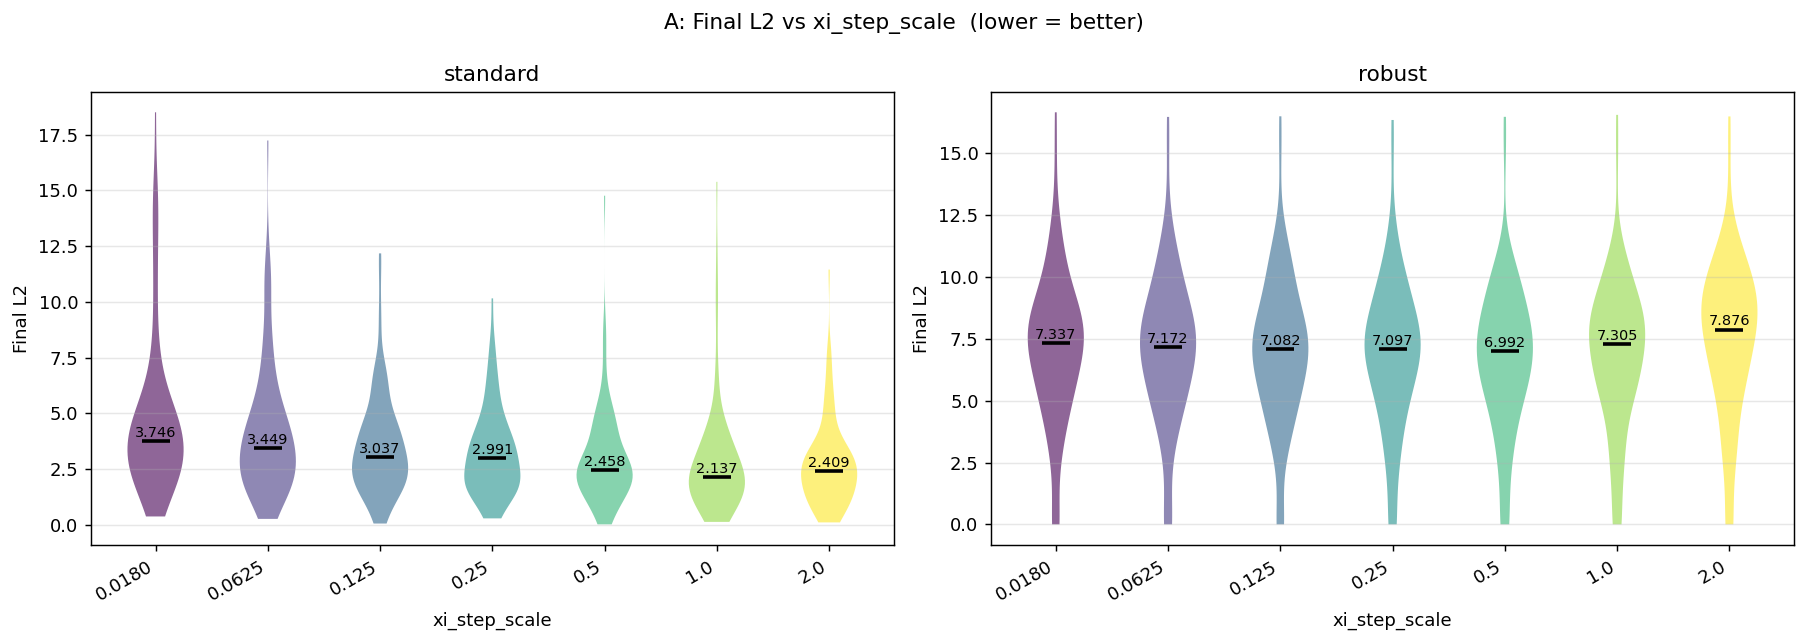

In [4]:
display(Image(filename=f'{OUT}/A_final_l2.png'))

## Plot B — Convergence curves

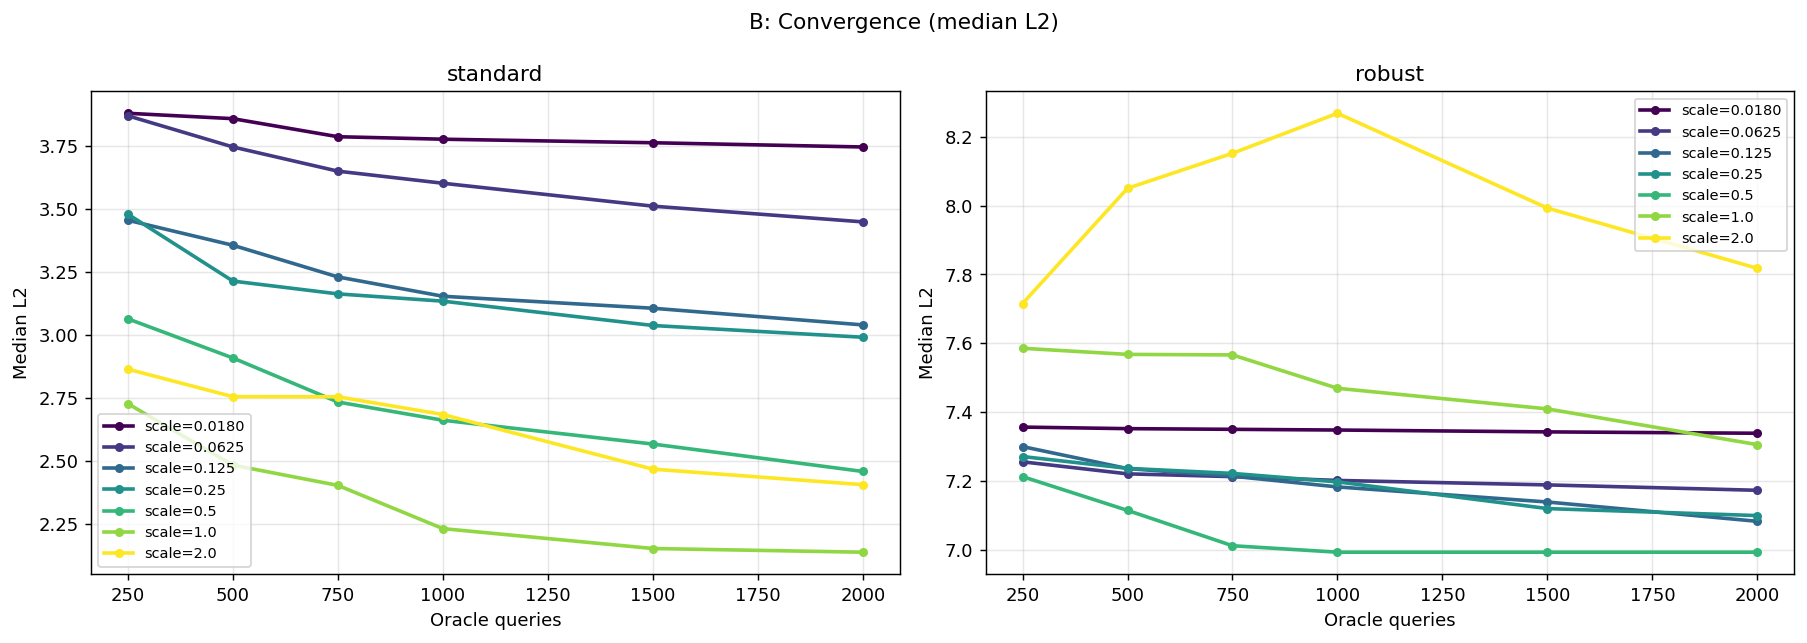

In [5]:
display(Image(filename=f'{OUT}/B_convergence.png'))

## Plot C — Improvement ratio vs xi_step_scale

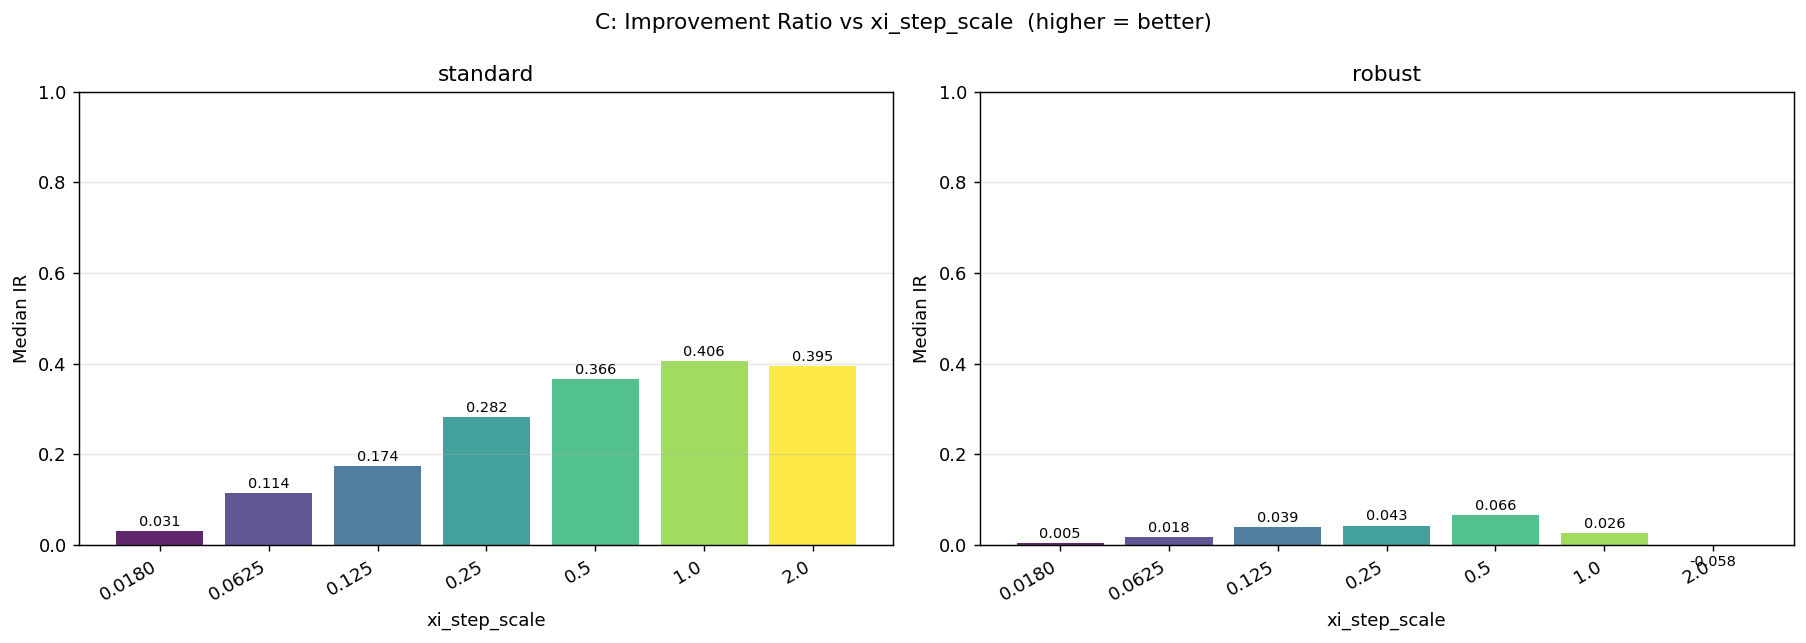

In [6]:
display(Image(filename=f'{OUT}/C_improvement_ratio.png'))

## Plot D — Generations completed in budget

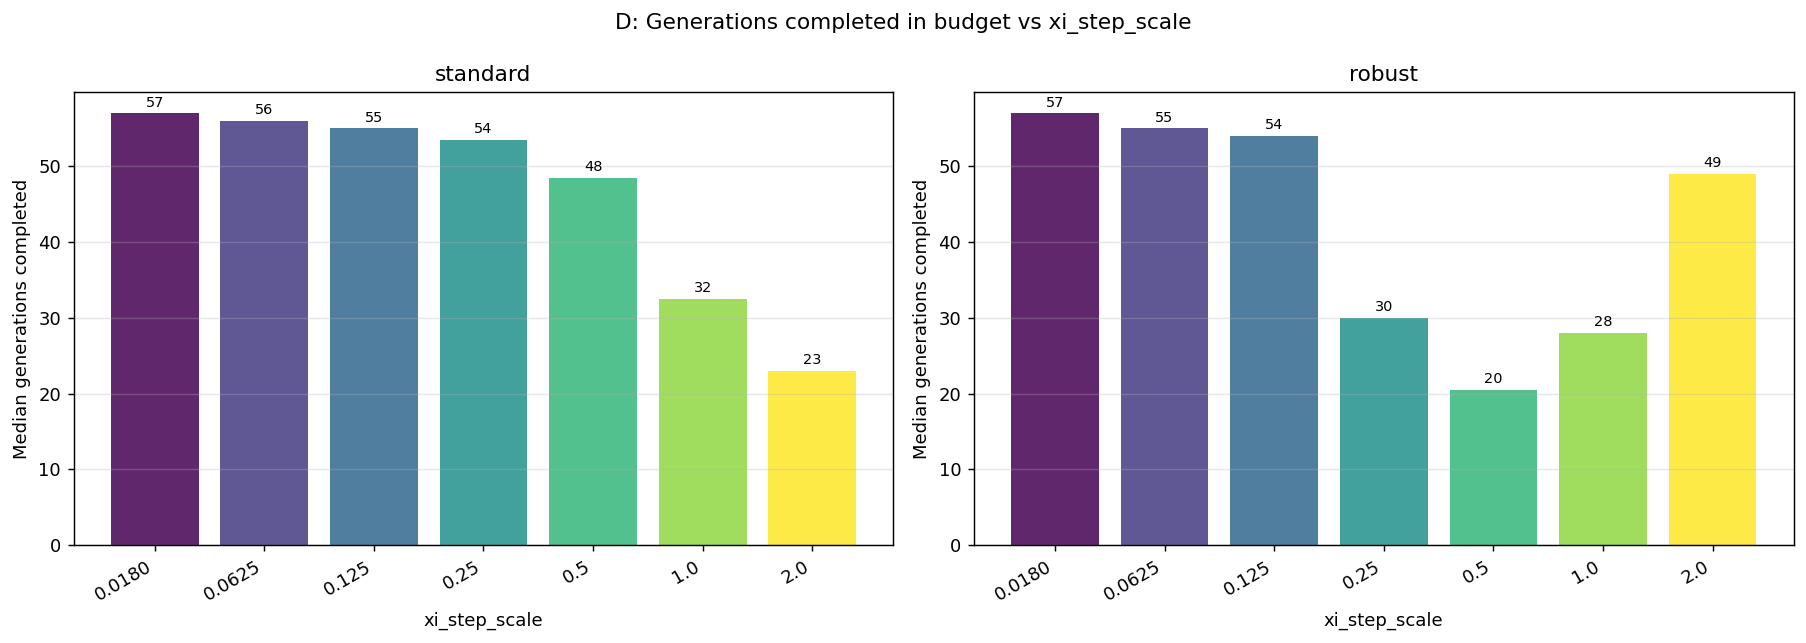

In [7]:
display(Image(filename=f'{OUT}/D_generations.png'))

## Plot E — Shrink/backtrack overhead per generation

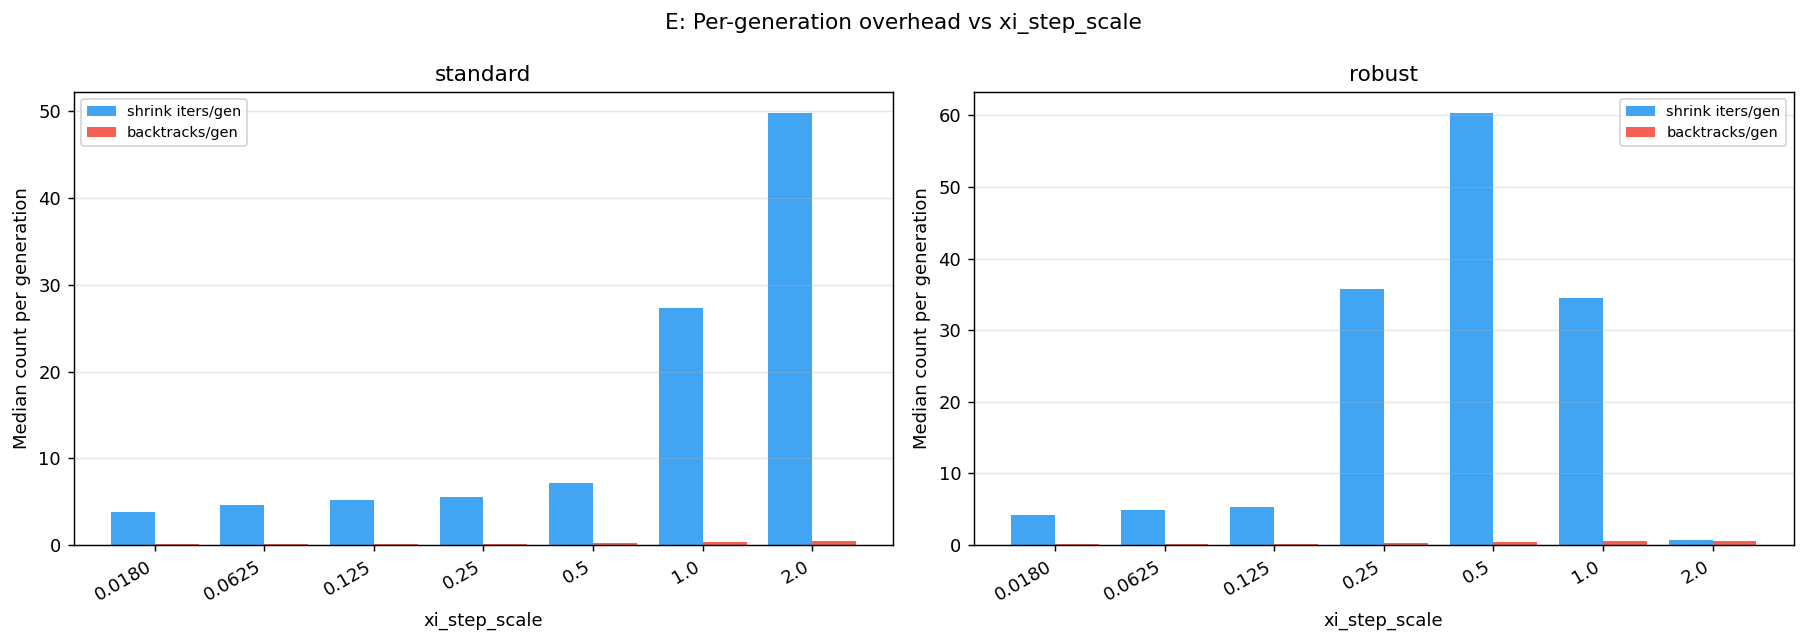

In [8]:
display(Image(filename=f'{OUT}/E_overhead.png'))

## Conclusions

1. **Standard model: keep `xi_step_scale=1.0`.** The relationship is smooth
   and monotonic across the whole grid — `1.0` sits at (or very near) the
   peak (IR=0.406). No hidden intermediate sweet spot.
2. **Robust model: switch to `xi_step_scale=0.5`.** This more than doubles
   the improvement ratio vs the previous best (0.066 vs 0.026 at `1.0`,
   vs 0.056 for Study 1's best robust config `lam_small`). `1.0` is
   apparently *too aggressive* a starting step for the robust model's
   flatter boundary.
3. **`xi_step_scale=2.0` should be avoided entirely**, especially for the
   robust model, where it makes the median run end up *worse* than its
   Phase-1 starting point.
4. **Trade-off if a single config is needed for both models**:
   `xi_step_scale=0.5` costs the standard model ~10% relative IR (0.366 vs
   0.406) but gives the robust model a 2.5× gain (0.066 vs 0.026) — likely
   the better overall choice if Stage 1's goal includes the robust model.
5. Recommended config going forward: **`xi_step_scale=0.5, bs_steps=15,
   tau=1, lam_override=14, cmu_scale=1.0`** — or a model-conditional choice
   (`1.0` for standard, `0.5` for robust) if per-model tuning is acceptable.
